# E-Commerce Customer Churn Prediction
---

## Project Overview

Customer churn is one of the biggest challenges in the e-commerce industry.
This notebook implements a **production-grade ML pipeline** with:

- Robust cross-validation using **Stratified K-Fold**
- Hyperparameter optimization using **GridSearchCV**
- **Bias-Variance tradeoff** analysis per model
- A comprehensive **final diagnostic dashboard** comparing all models
- **Customer segmentation** using RFM, K-Means, and DBSCAN

### Pipeline Steps
| Step | Description |
|------|-------------|
| 1 | Data Loading & Cleaning |
| 2 | Train/Test Split (no leakage) |
| 3 | Feature Engineering |
| 4 | Preprocessing Pipeline (log transform, imputation, scaling, encoding) |
| 5 | Class Balancing (SMOTETomek) |
| 6 | Stratified K-Fold Cross-Validation |
| 7 | GridSearchCV Hyperparameter Tuning |
| 8 | Bias-Variance Decomposition |
| 9 | Final Dashboard & Summary |
| 10 | Customer Segmentation (RFM, K-Means, DBSCAN) |


## 1. Import Libraries

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    GridSearchCV, cross_val_score, learning_curve
)
from sklearn.linear_model   import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier
from xgboost                import XGBClassifier
from sklearn.preprocessing  import StandardScaler
from sklearn.experimental   import enable_iterative_imputer  # noqa
from sklearn.impute         import IterativeImputer
from sklearn.metrics        import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score
)
from imblearn.combine import SMOTETomek

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
N_SPLITS     = 5          # K-Fold splits
MODEL_COLORS = ['steelblue', 'mediumseagreen', 'darkorange', 'tomato']
MODEL_NAMES  = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

print('Libraries imported.')

Libraries imported.


## 2. Load & Explore Data

In [50]:
df = pd.read_excel('D:\ERU\AitronixEnv\MKIIII\E Commerce Dataset (1).xlsx', sheet_name='E Comm')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


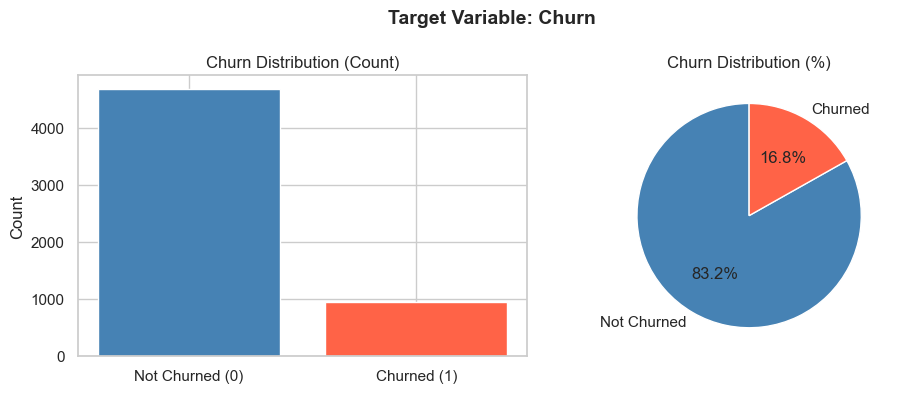

Class imbalance ratio: 4.94:1


In [51]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
churn_counts = df['Churn'].value_counts()
ax[0].bar(['Not Churned (0)', 'Churned (1)'], churn_counts.values, color=['steelblue', 'tomato'])
ax[0].set_title('Churn Distribution (Count)')
ax[0].set_ylabel('Count')
ax[1].pie(churn_counts.values, labels=['Not Churned', 'Churned'],
          autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
ax[1].set_title('Churn Distribution (%)')
plt.suptitle('Target Variable: Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Class imbalance ratio: {churn_counts[0]/churn_counts[1]:.2f}:1')

## 3. Data Cleaning

Remove `CustomerID` (no predictive value) and fix inconsistent categorical labels.

In [52]:
df = df.drop('CustomerID', axis=1)

df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({'Phone': 'Mobile Phone'})
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'CC': 'Credit Card',
    'COD': 'Cash on Delivery'
})
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})

print(f'Shape after cleaning: {df.shape}')
print('Labels standardized.')

Shape after cleaning: (5630, 19)
Labels standardized.


In [53]:
df["PreferedOrderCat"].value_counts()

PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64

In [54]:
df["PreferredPaymentMode"].value_counts()

PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64

## 4. Train / Test Split

> **Note:** Split happens **before all preprocessing** to prevent data leakage.
> The test set simulates unseen production data — it must never influence any fitting step.

In [55]:
x = df.drop('Churn', axis=1)
y = df['Churn']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.10, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {x_train.shape[0]} samples  |  Test: {x_test.shape[0]} samples')
print(f'Train class balance:\n{y_train.value_counts()}')

Train: 5067 samples  |  Test: 563 samples
Train class balance:
Churn
0    4214
1     853
Name: count, dtype: int64


## 5. Feature Engineering

In [56]:
# x_train
x_train['Spending_Per_Order'] = np.where(
    x_train['OrderCount'] == 0, 0,
    x_train['CashbackAmount'] / x_train['OrderCount']
)

x_train['Orders_Per_Tenure'] = np.where(
    (x_train['Tenure'] == 0) | (x_train['Tenure'].isnull()), 0,
    x_train['OrderCount'] / x_train['Tenure']
)

x_train['Recency_Ratio'] = np.where(
    x_train['Tenure'] == 0, 0,
    x_train['DaySinceLastOrder'] / x_train['Tenure']
)


# x_test
x_test['Spending_Per_Order'] = np.where(
    x_test['OrderCount'] == 0, 0,
    x_test['CashbackAmount'] / x_test['OrderCount']
)

x_test['Orders_Per_Tenure'] = np.where(
    (x_test['Tenure'] == 0) | (x_test['Tenure'].isnull()), 0,
    x_test['OrderCount'] / x_test['Tenure']
)

x_test['Recency_Ratio'] = np.where(
    x_test['Tenure'] == 0, 0,
    x_test['DaySinceLastOrder'] / x_test['Tenure']
)


print('New features: Spending_Per_Order, Orders_Per_Tenure, Recency_Ratio')

# describe
print(x_train[['Spending_Per_Order','Orders_Per_Tenure','Recency_Ratio']].describe())

New features: Spending_Per_Order, Orders_Per_Tenure, Recency_Ratio
       Spending_Per_Order  Orders_Per_Tenure  Recency_Ratio
count         4836.000000        4838.000000    4555.000000
mean            94.436794           0.604663       0.907663
std             54.170352           1.093414       1.474870
min              0.000000           0.000000       0.000000
25%             54.513333           0.080000       0.125000
50%             84.912500           0.200000       0.400000
75%            130.025000           0.666667       1.000000
max            298.590000          16.000000      15.000000


### Distribution of Numerical Columns — Before Transformation

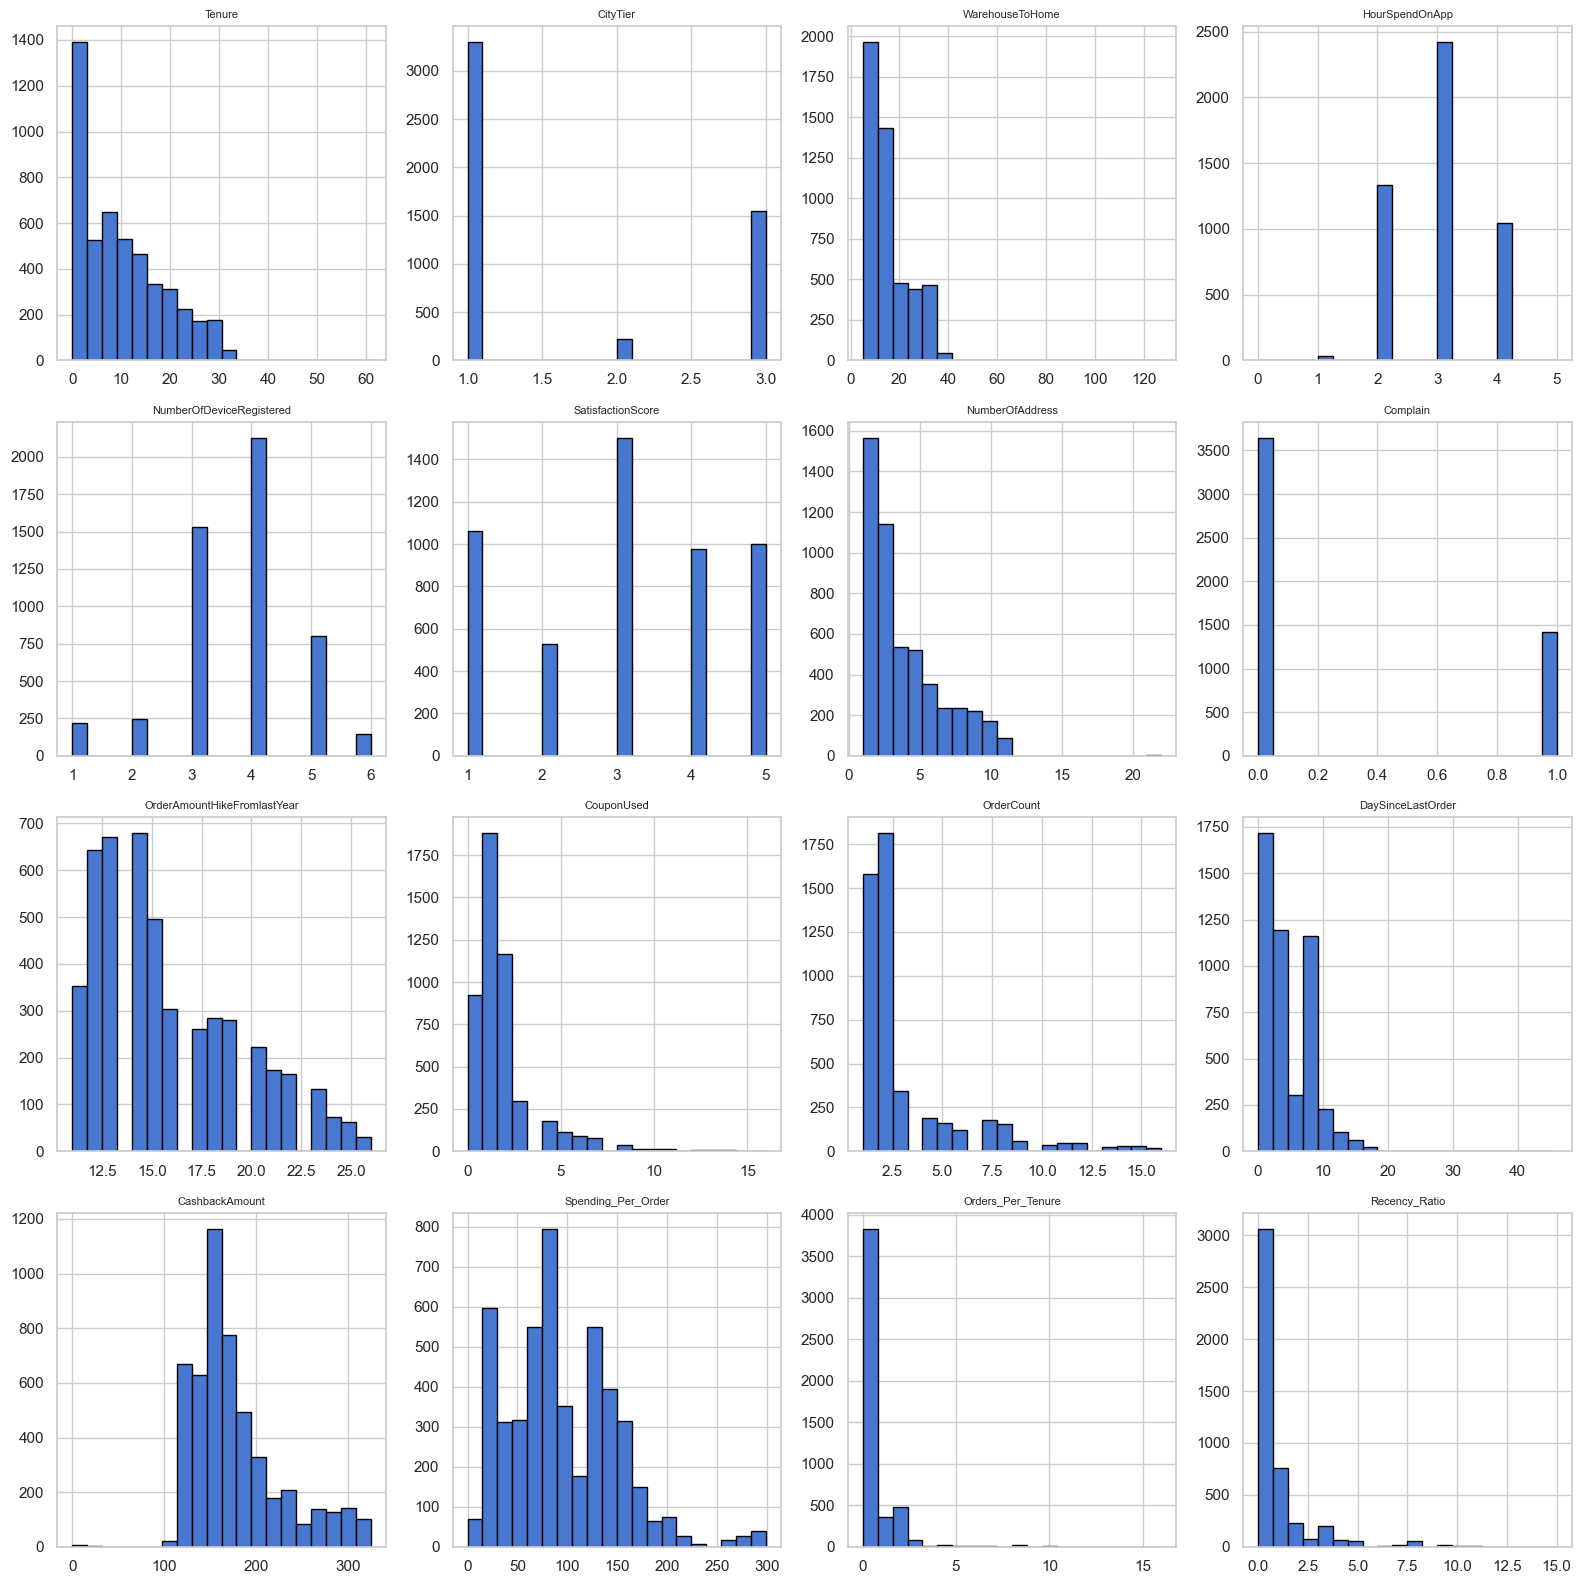

In [57]:
import math

numcols = x_train.select_dtypes(include=np.number).columns
n_cols = 4
n_rows = math.ceil(len(numcols) / n_cols)

plt.figure(figsize=(16, 4 * n_rows))
for idx, col in enumerate(numcols, 1):
    plt.subplot(n_rows, n_cols, idx)
    plt.hist(x_train[col], bins=20, edgecolor='black')
    plt.title(col, fontsize=8)
plt.tight_layout()
plt.show()

## 6. Preprocessing Pipeline

### Log Transform → Imputation → Scaling → Encoding

All steps are **fit on training data only**, then applied to test data.

In [58]:
num_col = x_train.select_dtypes(include=np.number).columns.tolist()

missing_col = [c for c in num_col if x_train[c].isna().sum() > 0]
if missing_col:
    imputer = IterativeImputer(random_state=RANDOM_STATE, max_iter=10)
    x_train[missing_col] = imputer.fit_transform(x_train[missing_col])
    x_test[missing_col]  = imputer.transform(x_test[missing_col])
    print(f'Imputed columns: {missing_col}')


# --- Log1p transform for skewed features ---
skewed_cols = ['Tenure', 'WarehouseToHome', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']
for col in skewed_cols:
    x_train[col] = np.log1p(x_train[col])
    x_test[col]  = np.log1p(x_test[col])


# --- Standard Scaling ---
scaler = StandardScaler()
x_train[num_col] = scaler.fit_transform(x_train[num_col])
x_test[num_col]  = scaler.transform(x_test[num_col])

# --- One-Hot Encoding ---
cat_col = x_train.select_dtypes(include='object').columns
x_train = pd.get_dummies(x_train, columns=cat_col, drop_first=True)
x_test  = pd.get_dummies(x_test,  columns=cat_col, drop_first=True)


print(f'Preprocessing complete. Final feature count: {x_train.shape[1]}')

Imputed columns: ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'Spending_Per_Order', 'Orders_Per_Tenure', 'Recency_Ratio']
Preprocessing complete. Final feature count: 28


### Distribution of Numerical Columns — After Transformation

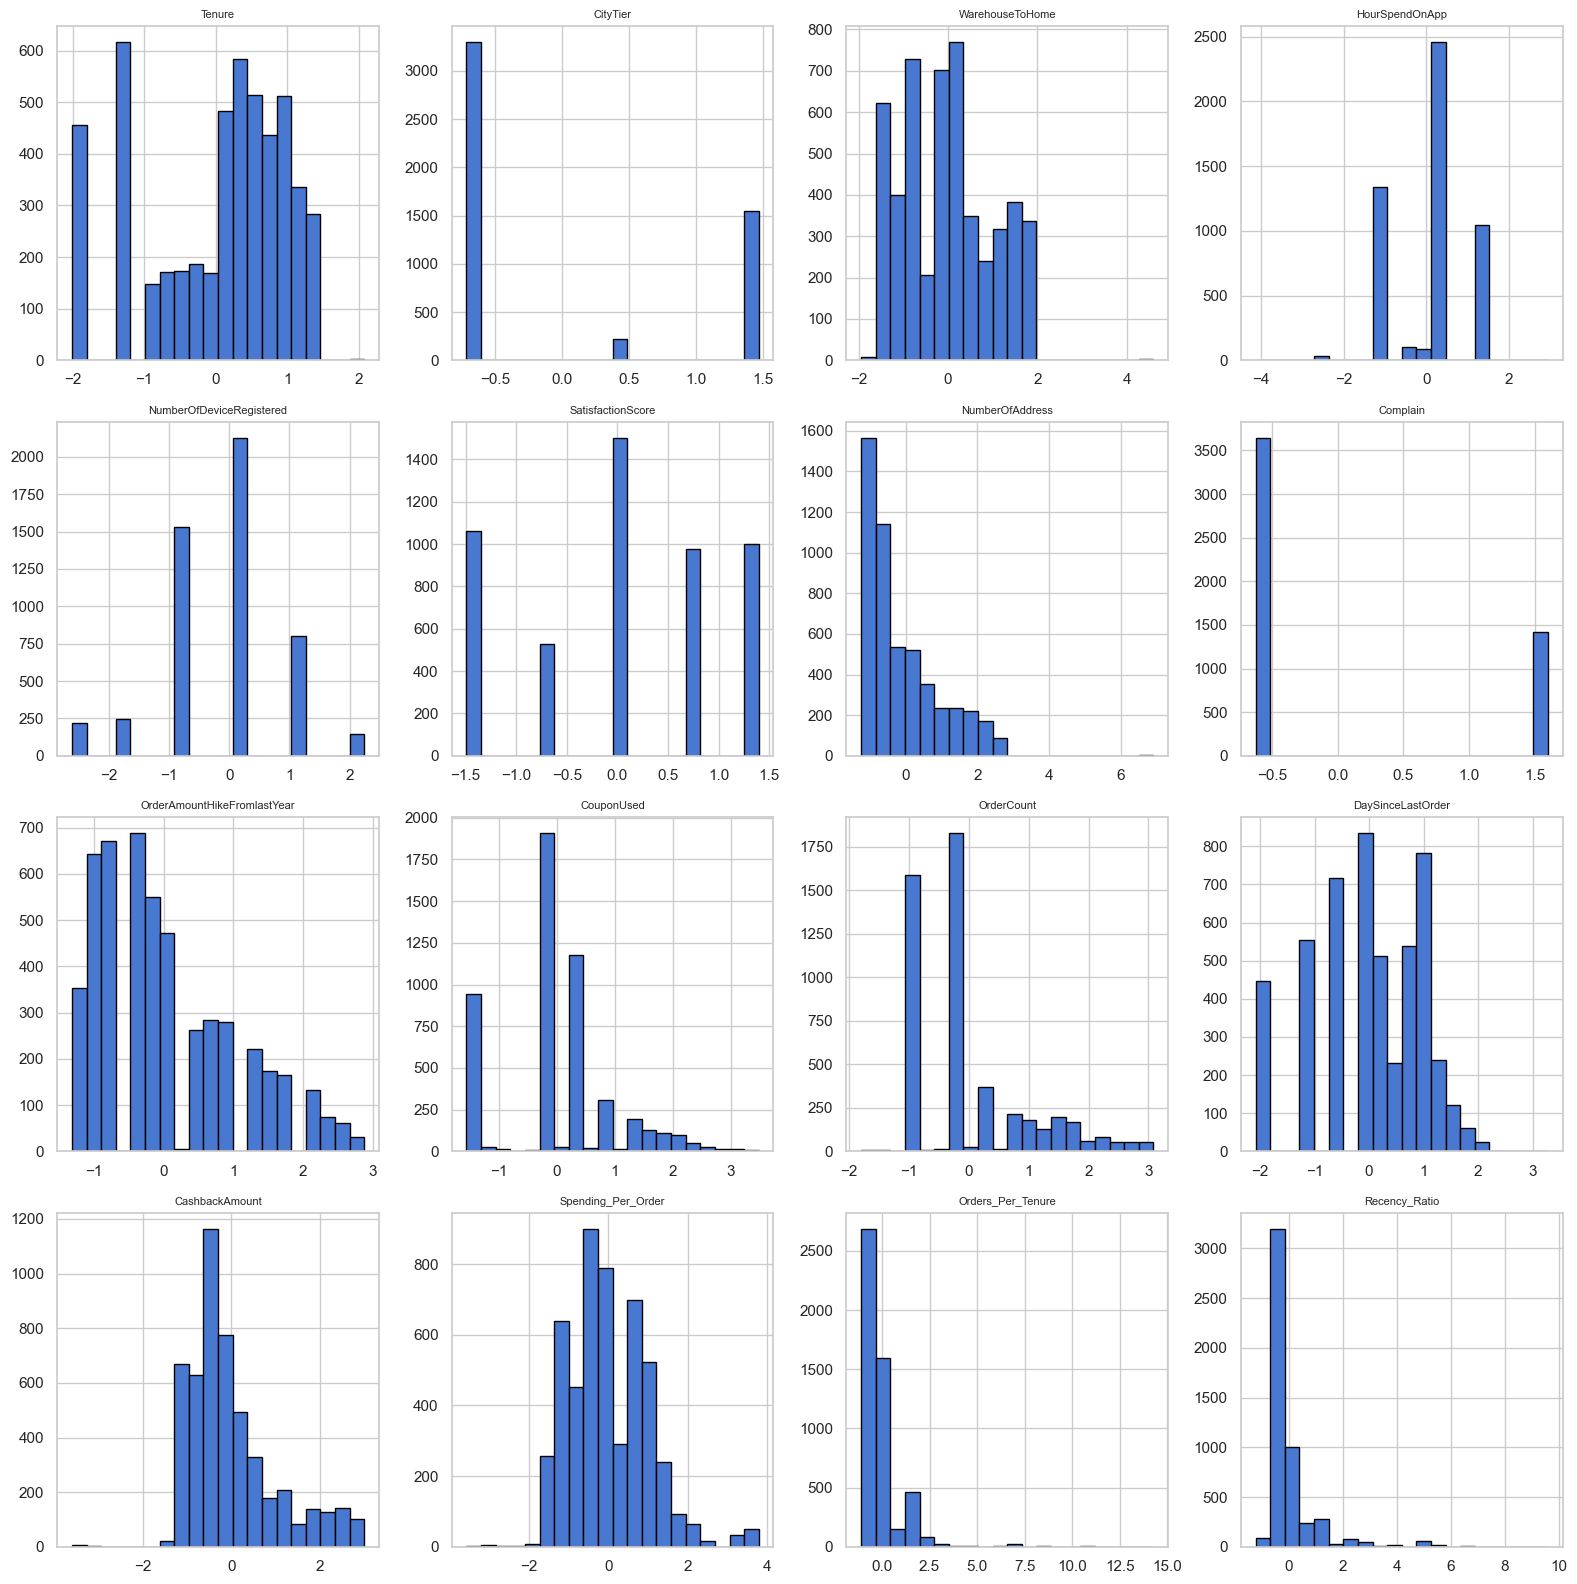

In [59]:
import math

numcols = x_train.select_dtypes(include=np.number).columns
n_cols = 4
n_rows = math.ceil(len(numcols) / n_cols)

plt.figure(figsize=(16, 4 * n_rows))
for idx, col in enumerate(numcols, 1):
    plt.subplot(n_rows, n_cols, idx)
    plt.hist(x_train[col], bins=20, edgecolor='black')
    plt.title(col, fontsize=8)
plt.tight_layout()
plt.show()

## 7. Class Balancing — SMOTETomek

**SMOTETomek** combines:
- **SMOTE**: Synthetic oversampling of the minority class (Churned)
- **Tomek Links**: Removes ambiguous borderline samples from the majority class

Applied **only to training data** — the test set stays untouched to reflect real-world distribution.

In [60]:
print('Before resampling:')
print(y_train.value_counts())

smt = SMOTETomek(random_state=RANDOM_STATE)
x_train, y_train = smt.fit_resample(x_train, y_train)

print('\nAfter resampling:')
print(y_train.value_counts())
print(f'Balanced dataset. Total training samples: {len(y_train)}')

Before resampling:
Churn
0    4214
1     853
Name: count, dtype: int64

After resampling:
Churn
1    4214
0    4214
Name: count, dtype: int64
Balanced dataset. Total training samples: 8428


## 8. Stratified K-Fold Cross-Validation

### What is K-Fold and Why?

Instead of evaluating on a single train/val split (which is sensitive to randomness),
**K-Fold CV** divides the training data into `K` equal folds and trains the model `K` times —
each time using a different fold as the validation set.

We use **Stratified K-Fold** to preserve the class ratio in each fold, essential for imbalanced datasets.

```
Fold 1: [VAL] [TRN] [TRN] [TRN] [TRN]  -> score_1
Fold 2: [TRN] [VAL] [TRN] [TRN] [TRN]  -> score_2
Fold 3: [TRN] [TRN] [VAL] [TRN] [TRN]  -> score_3
Fold 4: [TRN] [TRN] [TRN] [VAL] [TRN]  -> score_4
Fold 5: [TRN] [TRN] [TRN] [TRN] [VAL]  -> score_5
                                        -> Mean +/- Std
```

**Benefits:**
- More reliable estimate of generalization performance
- Detects variance issues (high std across folds = unstable model)
- Uses all data for both training and validation

In [61]:
# --- Define base models (before tuning) ---
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                         eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
}

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

kfold_results = {}

print(f'Running Stratified {N_SPLITS}-Fold CV on base models...\n')
print(f'{'Model':<25} {'Mean Acc':>10} {'Std':>8} {'Mean F1':>10} {'Std':>8}')
print('-' * 65)

for name, model in base_models.items():
    acc_scores = cross_val_score(model, x_train, y_train, cv=skf, scoring='accuracy',  n_jobs=-1)
    f1_scores  = cross_val_score(model, x_train, y_train, cv=skf, scoring='f1',        n_jobs=-1)
    auc_scores = cross_val_score(model, x_train, y_train, cv=skf, scoring='roc_auc',   n_jobs=-1)

    kfold_results[name] = {
        'acc_scores': acc_scores,
        'f1_scores':  f1_scores,
        'auc_scores': auc_scores,
        'mean_acc':   acc_scores.mean(),
        'std_acc':    acc_scores.std(),
        'mean_f1':    f1_scores.mean(),
        'std_f1':     f1_scores.std(),
        'mean_auc':   auc_scores.mean(),
        'std_auc':    auc_scores.std(),
    }
    print(f'{name:<25} {acc_scores.mean():>10.4f} {acc_scores.std():>8.4f} {f1_scores.mean():>10.4f} {f1_scores.std():>8.4f}')

print('K-Fold CV complete.')

Running Stratified 5-Fold CV on base models...

Model                       Mean Acc      Std    Mean F1      Std
-----------------------------------------------------------------
Logistic Regression           0.8439   0.0091     0.8434   0.0092
Decision Tree                 0.8945   0.0110     0.8929   0.0121
Random Forest                 0.9498   0.0058     0.9499   0.0059
XGBoost                       0.9738   0.0048     0.9739   0.0046
K-Fold CV complete.


### K-Fold Results Visualization

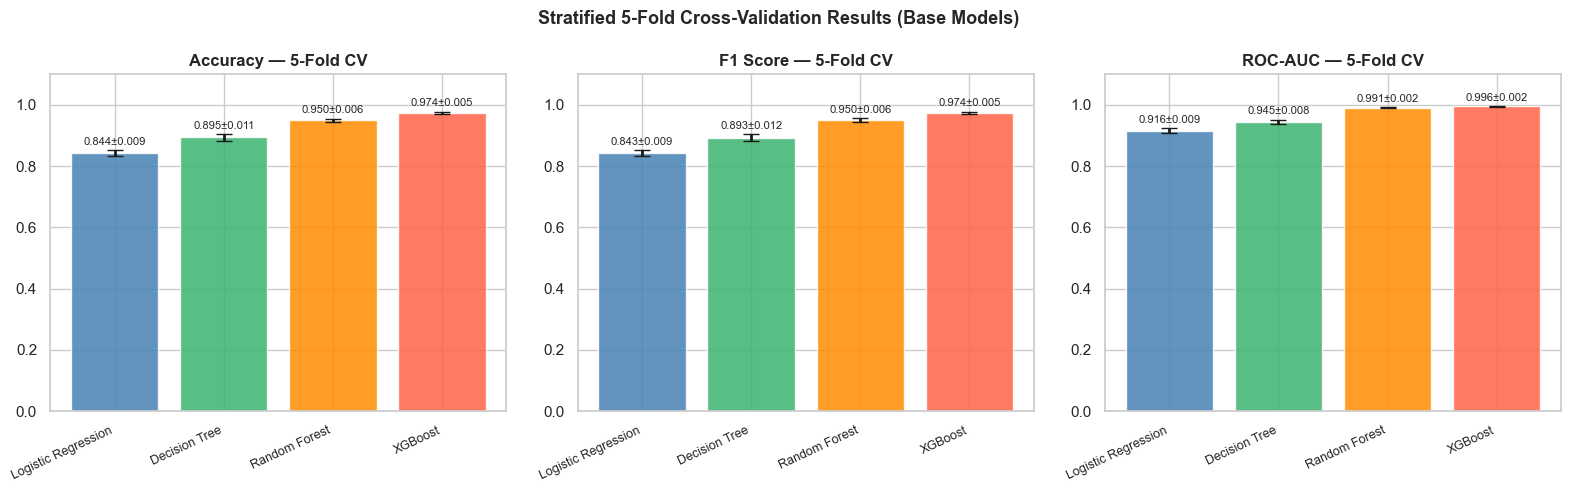

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_kf = [('acc_scores', 'Accuracy'), ('f1_scores', 'F1 Score'), ('auc_scores', 'ROC-AUC')]

for ax, (key, title) in zip(axes, metrics_kf):
    data   = [kfold_results[n][key] for n in MODEL_NAMES]
    means  = [d.mean() for d in data]
    stds   = [d.std()  for d in data]

    bars = ax.bar(MODEL_NAMES, means, color=MODEL_COLORS, alpha=0.85,
                  yerr=stds, capsize=6, error_kw={'linewidth': 2})
    ax.set_title(f'{title} — {N_SPLITS}-Fold CV', fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(MODEL_NAMES, rotation=25, ha='right', fontsize=9)
    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + std + 0.01,
                f'{mean:.3f}±{std:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(f'Stratified {N_SPLITS}-Fold Cross-Validation Results (Base Models)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

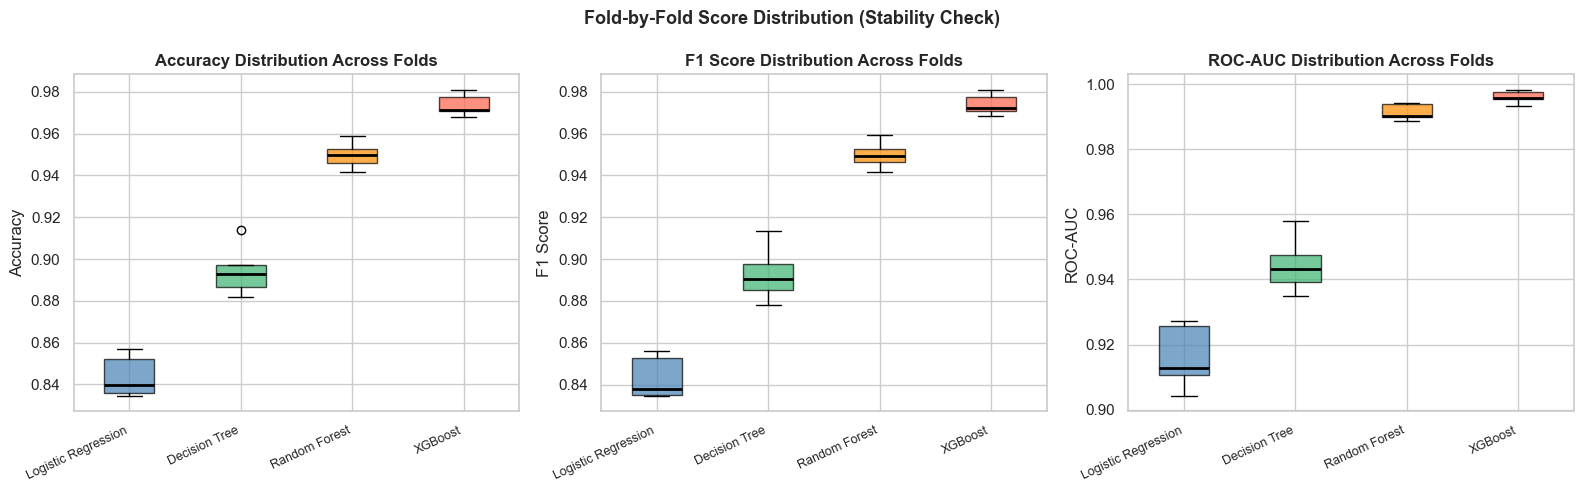

In [63]:
# --- Box plots showing fold-by-fold variance ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (key, title) in zip(axes, metrics_kf):
    data = [kfold_results[n][key] for n in MODEL_NAMES]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], MODEL_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(MODEL_NAMES, rotation=25, ha='right', fontsize=9)
    ax.set_title(f'{title} Distribution Across Folds', fontweight='bold')
    ax.set_ylabel(title)

plt.suptitle('Fold-by-Fold Score Distribution (Stability Check)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 9. Hyperparameter Tuning — GridSearchCV

### What is GridSearchCV?

**GridSearchCV** exhaustively searches over a defined parameter grid, evaluating each combination
using K-Fold CV. It picks the combination that maximizes the chosen metric.

```
Parameter Grid Example (Decision Tree):
  max_depth:        [3, 5, 8, 10]
  min_samples_leaf: [5, 10, 20]
  criterion:        ['gini', 'entropy']
  ->
  4 x 3 x 2 = 24 combinations x 5 folds = 120 fits
```

> Tuning is done on **F1 score** (better for imbalanced classification than accuracy).

> This cell may take a few minutes — it performs an exhaustive search.

In [64]:
param_grids = {
    'Logistic Regression': {
        'C':       [0.01, 0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver':  ['liblinear', 'saga'],
    },
    'Decision Tree': {
        'max_depth':        [3, 5, 8, 10, None],
        'min_samples_leaf': [5, 10, 20],
        'criterion':        ['gini', 'entropy'],
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth':    [8, 12, None],
        'max_features': ['sqrt', 'log2'],
    },
    'XGBoost': {
        'n_estimators':    [100, 200],
        'max_depth':       [4, 6, 8],
        'learning_rate':   [0.05, 0.1, 0.2],
        'subsample':       [0.7, 1.0],
    },
}

estimators = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':             XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
}

grid_search_results = {}
best_models         = {}

print(f'Running GridSearchCV with {N_SPLITS}-Fold CV (scoring = F1)...\n')

for name in MODEL_NAMES:
    print(f'Tuning {name}...')
    gs = GridSearchCV(
        estimators[name],
        param_grids[name],
        cv=skf,
        scoring='f1',
        n_jobs=-1,
        refit=True,
        verbose=0
    )
    gs.fit(x_train, y_train)

    grid_search_results[name] = gs
    best_models[name]         = gs.best_estimator_

    print(f'   Best params : {gs.best_params_}')
    print(f'   Best CV F1  : {gs.best_score_:.4f}\n')

print('GridSearchCV complete for all models.')

Running GridSearchCV with 5-Fold CV (scoring = F1)...

Tuning Logistic Regression...


   Best params : {'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}
   Best CV F1  : 0.8457

Tuning Decision Tree...
   Best params : {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 5}
   Best CV F1  : 0.9404

Tuning Random Forest...
   Best params : {'max_depth': None, 'max_features': 'log2', 'n_estimators': 100}
   Best CV F1  : 0.9845

Tuning XGBoost...
   Best params : {'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 200, 'subsample': 1.0}
   Best CV F1  : 0.9908

GridSearchCV complete for all models.


### Best Parameters Summary

In [65]:
best_params_summary = pd.DataFrame([
    {
        'Model':          name,
        'Best CV F1':     round(grid_search_results[name].best_score_, 4),
        'Best Params':    str(grid_search_results[name].best_params_)
    }
    for name in MODEL_NAMES
])

display(best_params_summary.style
        .highlight_max(subset=['Best CV F1'], color='lightgreen')
        .set_caption('GridSearchCV — Best Parameters'))

,Model,Best CV F1,Best Params
0,Logistic Regression,0.845700,"{'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}"
1,Decision Tree,0.940400,"{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 5}"
2,Random Forest,0.984500,"{'max_depth': None, 'max_features': 'log2', 'n_estimators': 100}"
3,XGBoost,0.990800,"{'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 200, 'subsample': 1.0}"


### Before vs After Tuning — CV Score Comparison

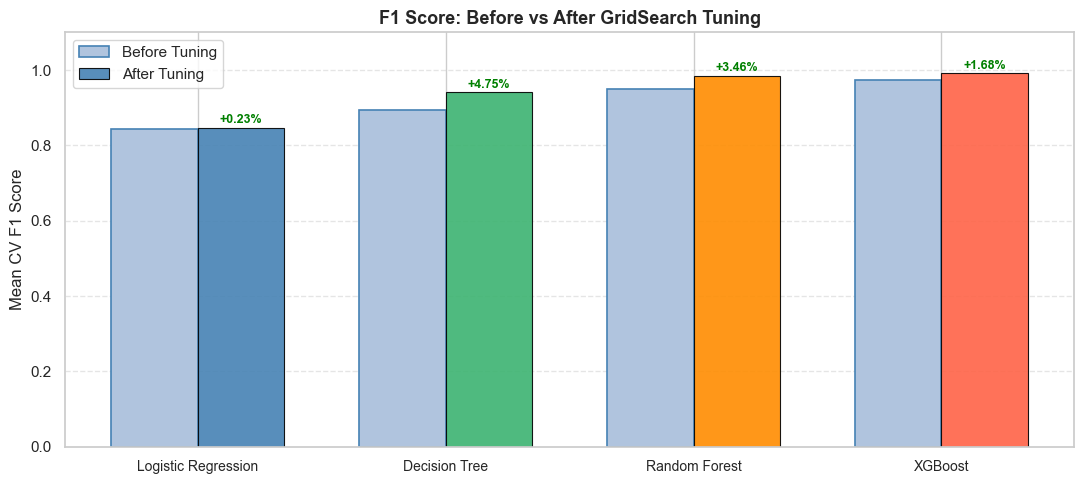

In [66]:
before_f1 = [kfold_results[n]['mean_f1']                     for n in MODEL_NAMES]
after_f1  = [grid_search_results[n].best_score_               for n in MODEL_NAMES]
gains     = [round((a - b) * 100, 2) for a, b in zip(after_f1, before_f1)]

x_pos = np.arange(len(MODEL_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x_pos - width/2, before_f1, width, label='Before Tuning', color='lightsteelblue', edgecolor='steelblue', linewidth=1.2)
bars2 = ax.bar(x_pos + width/2, after_f1,  width, label='After Tuning',  color=MODEL_COLORS,    edgecolor='black',     linewidth=0.8, alpha=0.9)

for bar, gain in zip(bars2, gains):
    color = 'green' if gain > 0 else 'red'
    sign  = '+' if gain >= 0 else ''
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{sign}{gain}%', ha='center', va='bottom', fontsize=9,
            color=color, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(MODEL_NAMES, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Mean CV F1 Score')
ax.set_title('F1 Score: Before vs After GridSearch Tuning', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---

## 10. Evaluate Tuned Models on Test Set

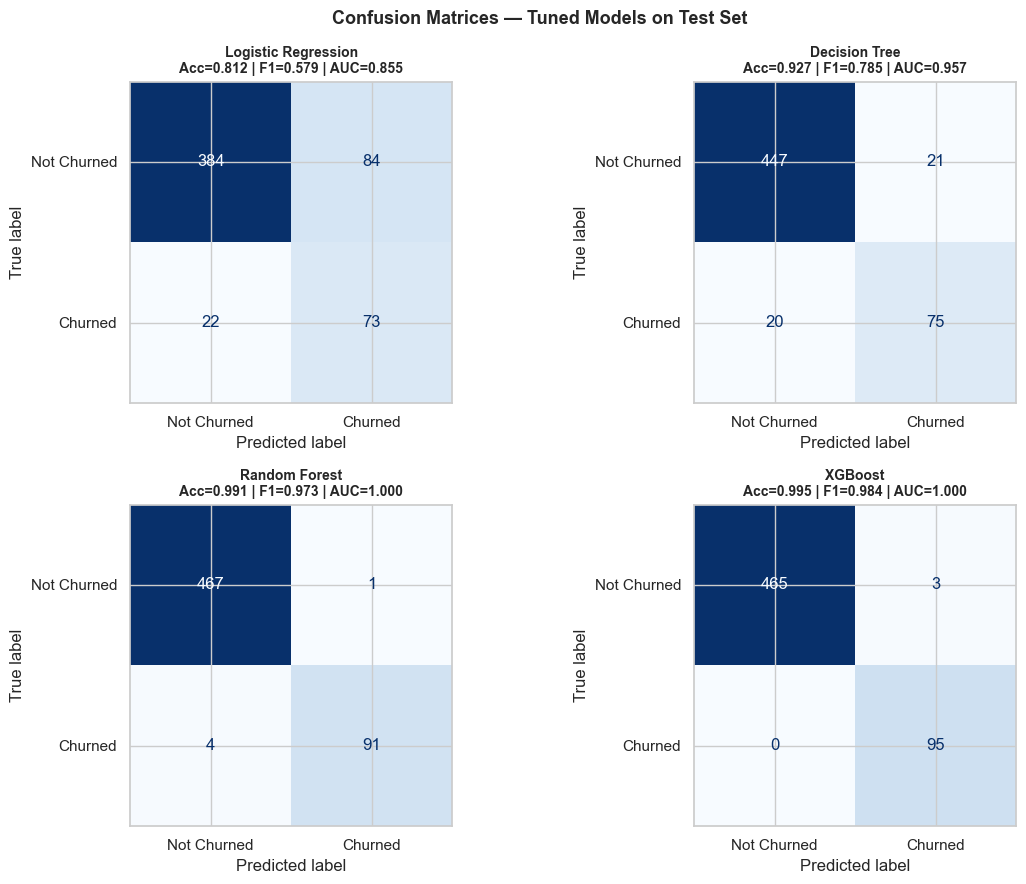

In [67]:
test_results = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, name in enumerate(MODEL_NAMES):
    model  = best_models[name]
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred)
    rep  = classification_report(y_test, y_pred, output_dict=True)

    test_results[name] = {
        'y_pred': y_pred, 'y_prob': y_prob,
        'Accuracy': round(acc, 4),
        'ROC-AUC':  round(auc, 4),
        'F1 (Churn)':        round(f1, 4),
        'Precision (Churn)': round(rep['1']['precision'], 4),
        'Recall (Churn)':    round(rep['1']['recall'],    4),
    }

    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Churned', 'Churned'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{name}\nAcc={acc:.3f} | F1={f1:.3f} | AUC={auc:.3f}', fontweight='bold', fontsize=10)

plt.suptitle('Confusion Matrices — Tuned Models on Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 11. Bias-Variance Analysis

### Understanding the Bias-Variance Tradeoff

Every ML model's error has two key components:

| Component | Meaning | Sign |
|-----------|---------|------|
| **Bias** | How wrong the model is on average (underfitting) | High train error |
| **Variance** | How much the model fluctuates with different data (overfitting) | Big gap: train >> val |
| **Noise** | Irreducible error in the data | Unavoidable |

```
Total Error = Bias^2 + Variance + Noise

Ideal model:  Low Bias + Low Variance
Overfitting:  Low Bias + High Variance   -> Train acc >> Val acc
Underfitting: High Bias + Low Variance   -> Both train and val acc are low
```

We measure this using the **gap between training score and validation score** across K-Fold folds:
- **Bias proxy** = 1 - mean training accuracy
- **Variance proxy** = std of validation scores across folds
- **Overfitting gap** = mean train accuracy - mean val accuracy

In [68]:
bias_variance_results = {}

print(f'Running Bias-Variance analysis ({N_SPLITS}-Fold)...\n')
print(f'{'Model':<25} {'Train Acc':>10} {'Val Acc':>10} {'Gap (Overfit)':>15} {'Val Std (Var)':>14} {'Diagnosis':>15}')
print('-' * 90)

for name in MODEL_NAMES:
    model = best_models[name]

    # Training scores
    train_scores = cross_val_score(model, x_train, y_train, cv=skf,
                                   scoring='accuracy', n_jobs=-1)
    # Validation scores (standard cross_val_score = val scores)
    val_scores   = cross_val_score(model, x_train, y_train, cv=skf,
                                   scoring='accuracy', n_jobs=-1)

    # Use learning_curve for proper train vs val split
    lc_sizes, lc_train, lc_val = learning_curve(
        model, x_train, y_train,
        cv=skf, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )

    mean_train = lc_train[-1].mean()   # train acc at full data
    mean_val   = lc_val[-1].mean()     # val acc at full data
    val_std    = lc_val[-1].std()      # variance proxy
    gap        = mean_train - mean_val # overfitting gap
    bias_proxy = 1 - mean_val          # bias proxy (error rate)

    if gap > 0.10:
        diagnosis = 'Overfit'
    elif bias_proxy > 0.15:
        diagnosis = 'Underfit'
    else:
        diagnosis = 'Good Fit'

    bias_variance_results[name] = {
        'lc_sizes':    lc_sizes,
        'lc_train':    lc_train,
        'lc_val':      lc_val,
        'mean_train':  mean_train,
        'mean_val':    mean_val,
        'val_std':     val_std,
        'gap':         gap,
        'bias_proxy':  bias_proxy,
        'diagnosis':   diagnosis,
    }

    print(f'{name:<25} {mean_train:>10.4f} {mean_val:>10.4f} {gap:>15.4f} {val_std:>14.4f} {diagnosis:>15}')

print('Bias-Variance analysis complete.')

Running Bias-Variance analysis (5-Fold)...

Model                      Train Acc    Val Acc   Gap (Overfit)  Val Std (Var)       Diagnosis
------------------------------------------------------------------------------------------
Logistic Regression           0.8477     0.8466          0.0011         0.0075        Underfit
Decision Tree                 0.9763     0.9403          0.0360         0.0054        Good Fit
Random Forest                 1.0000     0.9847          0.0153         0.0045        Good Fit
XGBoost                       1.0000     0.9902          0.0098         0.0024        Good Fit
Bias-Variance analysis complete.


### Bias-Variance Visualization

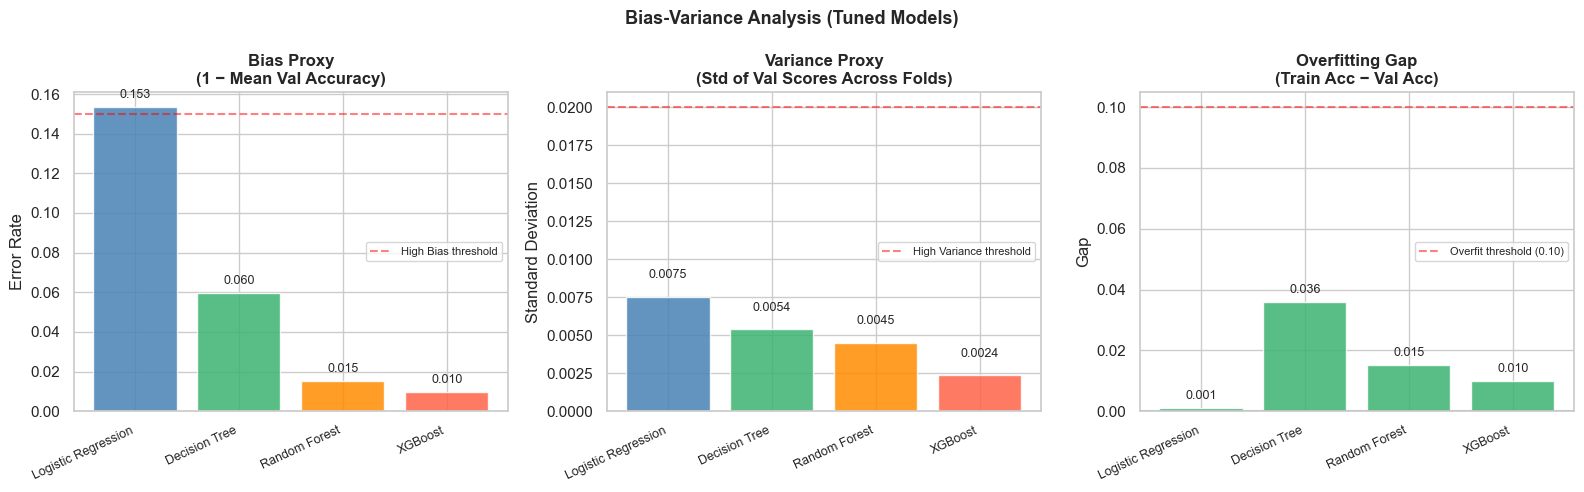

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Bias proxy (1 - val acc)
bias_vals = [bias_variance_results[n]['bias_proxy'] for n in MODEL_NAMES]
axes[0].bar(MODEL_NAMES, bias_vals, color=MODEL_COLORS, alpha=0.85)
axes[0].set_title('Bias Proxy\n(1 − Mean Val Accuracy)', fontweight='bold')
axes[0].set_ylabel('Error Rate')
axes[0].set_xticklabels(MODEL_NAMES, rotation=25, ha='right', fontsize=9)
axes[0].axhline(0.15, color='red', linestyle='--', alpha=0.5, label='High Bias threshold')
axes[0].legend(fontsize=8)
for bar, val in zip(axes[0].patches, bias_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Variance proxy (val std)
var_vals = [bias_variance_results[n]['val_std'] for n in MODEL_NAMES]
axes[1].bar(MODEL_NAMES, var_vals, color=MODEL_COLORS, alpha=0.85)
axes[1].set_title('Variance Proxy\n(Std of Val Scores Across Folds)', fontweight='bold')
axes[1].set_ylabel('Standard Deviation')
axes[1].set_xticklabels(MODEL_NAMES, rotation=25, ha='right', fontsize=9)
axes[1].axhline(0.02, color='red', linestyle='--', alpha=0.5, label='High Variance threshold')
axes[1].legend(fontsize=8)
for bar, val in zip(axes[1].patches, var_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# Plot 3: Overfitting gap
gap_vals = [bias_variance_results[n]['gap'] for n in MODEL_NAMES]
bar_colors = ['tomato' if g > 0.10 else 'mediumseagreen' for g in gap_vals]
axes[2].bar(MODEL_NAMES, gap_vals, color=bar_colors, alpha=0.85)
axes[2].set_title('Overfitting Gap\n(Train Acc − Val Acc)', fontweight='bold')
axes[2].set_ylabel('Gap')
axes[2].set_xticklabels(MODEL_NAMES, rotation=25, ha='right', fontsize=9)
axes[2].axhline(0.10, color='red', linestyle='--', alpha=0.5, label='Overfit threshold (0.10)')
axes[2].axhline(0,    color='black', linestyle='-',  alpha=0.3)
axes[2].legend(fontsize=8)
for bar, val in zip(axes[2].patches, gap_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Bias-Variance Analysis (Tuned Models)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 12. Grand Final Dashboard

### All Learning Curves + Overfitting Analysis in One View

This dashboard combines:
- **Row 1**: Learning curves for all 4 models (training vs validation accuracy over dataset size)
- **Row 2**: Overfitting comparison — train vs val accuracy + the gap
- **Row 3**: ROC curves + final test set metrics comparison

A **well-fit model** shows train and val curves converging as data increases.
An **overfitting model** shows a persistent large gap between train and val.

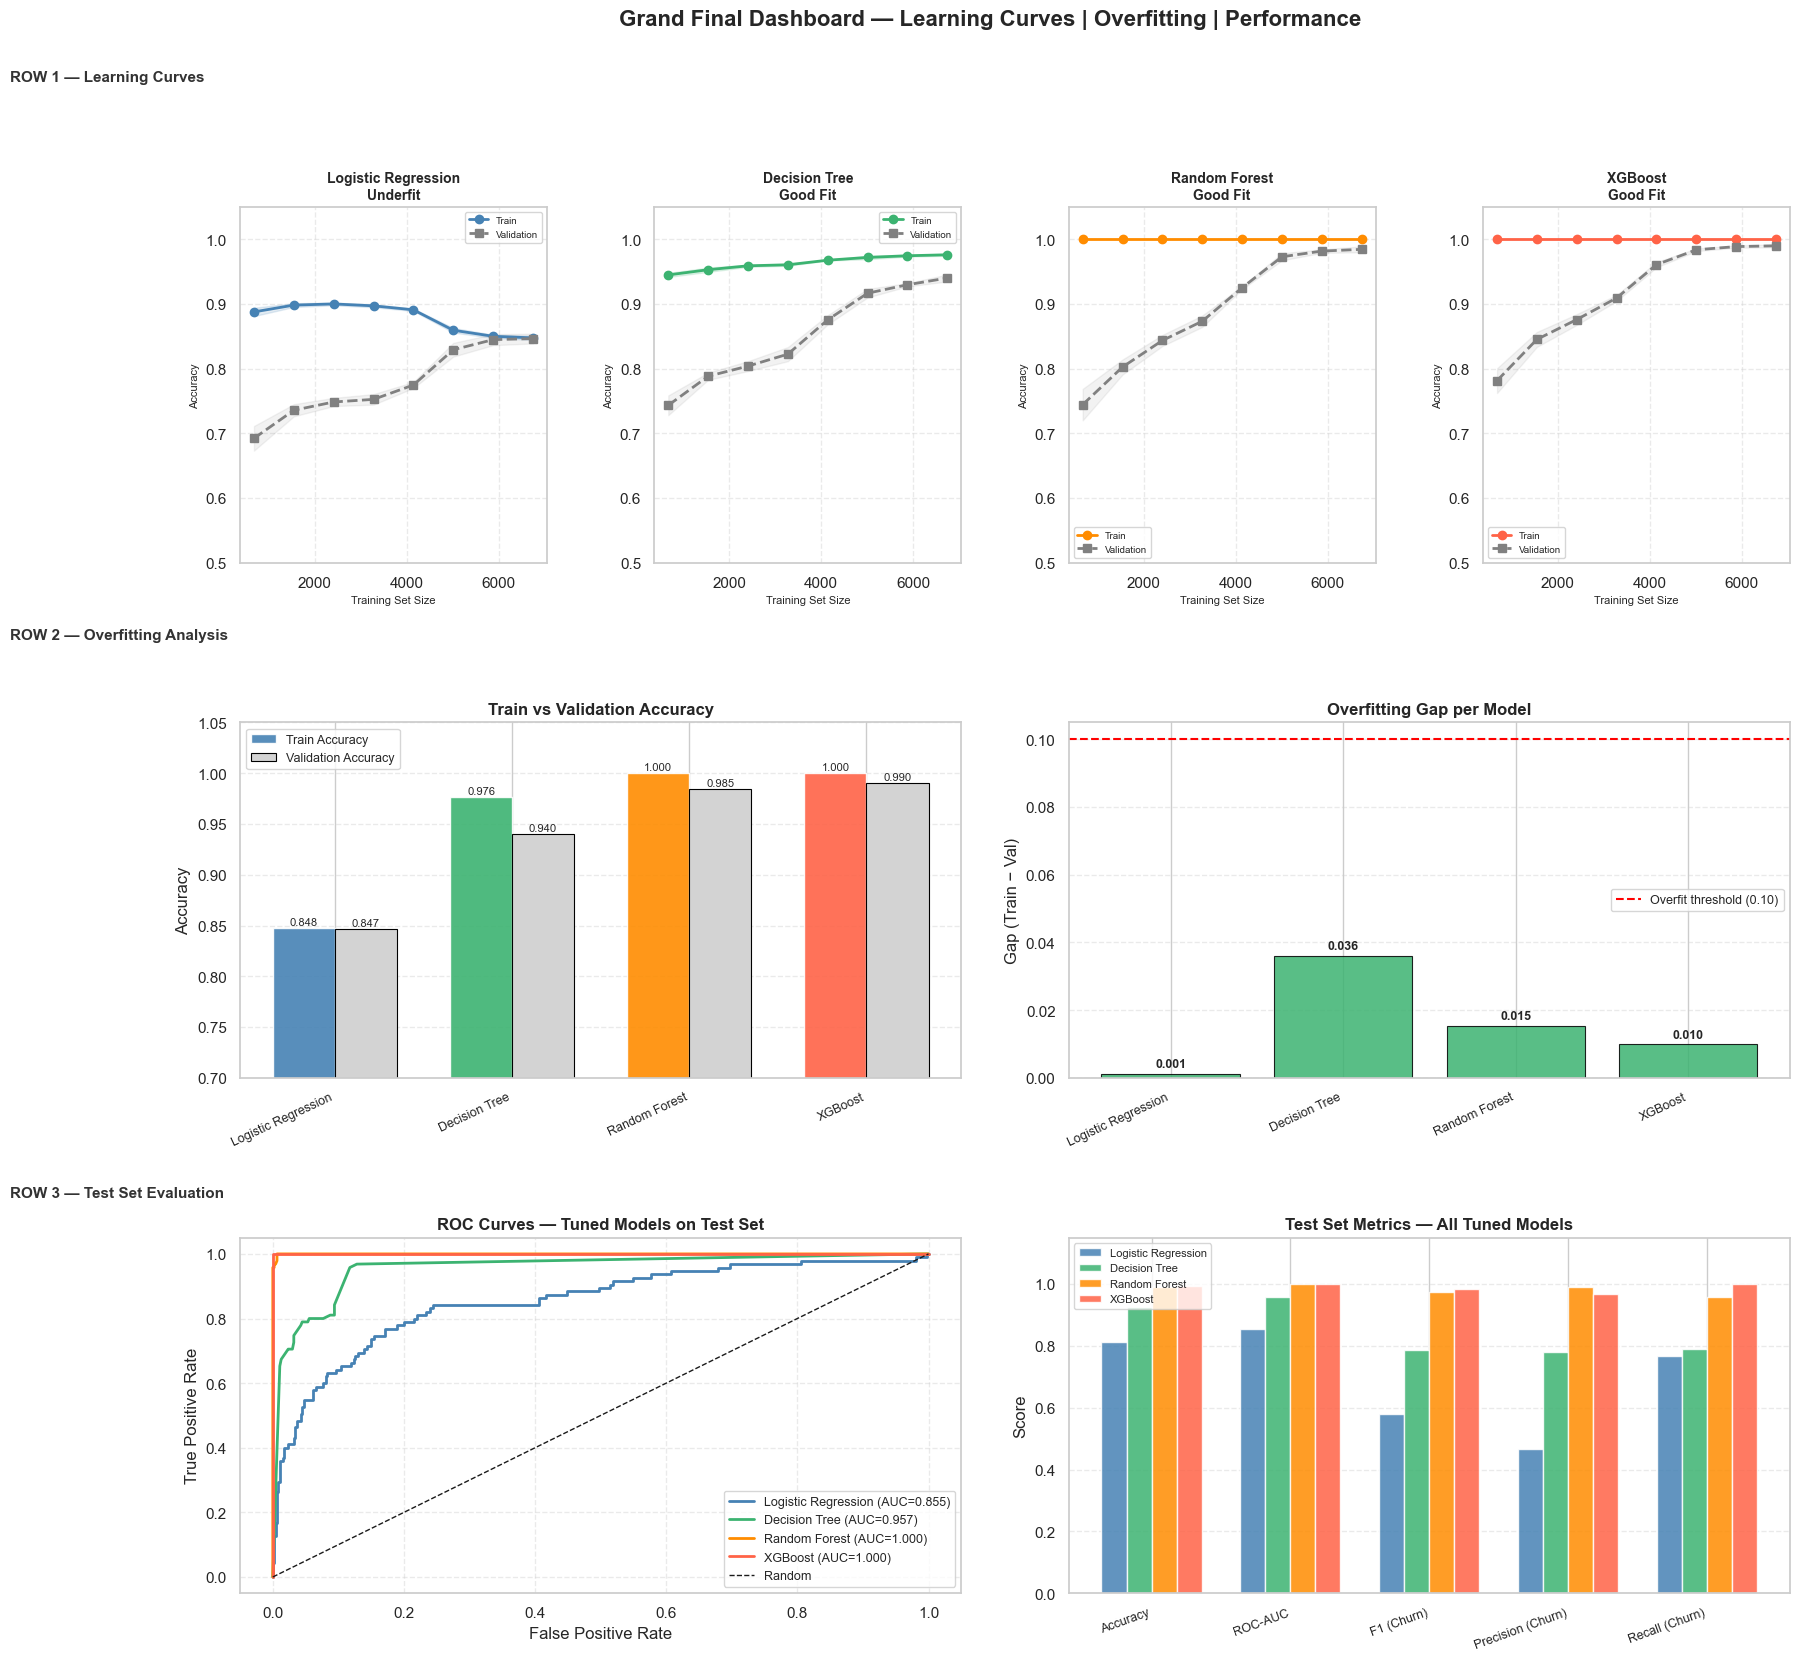

Dashboard saved as grand_dashboard.png


In [70]:
fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── ROW 1: Learning Curves ──────────────────────────────────────────────────
for col, name in enumerate(MODEL_NAMES):
    ax   = fig.add_subplot(gs[0, col])
    bvr  = bias_variance_results[name]
    sizes       = bvr['lc_sizes']
    train_mean  = bvr['lc_train'].mean(axis=1)
    train_std   = bvr['lc_train'].std(axis=1)
    val_mean    = bvr['lc_val'].mean(axis=1)
    val_std     = bvr['lc_val'].std(axis=1)
    color       = MODEL_COLORS[col]

    ax.plot(sizes, train_mean, 'o-', color=color,    label='Train',      lw=2)
    ax.plot(sizes, val_mean,   's--', color='gray',  label='Validation', lw=2)
    ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=color)
    ax.fill_between(sizes, val_mean   - val_std,   val_mean   + val_std,   alpha=0.10, color='gray')
    ax.set_title(f'{name}\n{bvr["diagnosis"]}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Training Set Size', fontsize=8)
    ax.set_ylabel('Accuracy',          fontsize=8)
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=7)
    ax.grid(True, linestyle='--', alpha=0.4)

fig.text(0.01, 0.95, 'ROW 1 — Learning Curves', fontsize=11, fontweight='bold', color='#333')

# ── ROW 2: Train vs Val + Gap ────────────────────────────────────────────────
ax2a = fig.add_subplot(gs[1, :2])  # train vs val bars
ax2b = fig.add_subplot(gs[1, 2:])  # overfitting gap bars

train_accs = [bias_variance_results[n]['mean_train'] for n in MODEL_NAMES]
val_accs   = [bias_variance_results[n]['mean_val']   for n in MODEL_NAMES]
gap_vals   = [bias_variance_results[n]['gap']        for n in MODEL_NAMES]

x_pos = np.arange(len(MODEL_NAMES))
w = 0.35
ax2a.bar(x_pos - w/2, train_accs, w, label='Train Accuracy',      color=MODEL_COLORS, alpha=0.9)
ax2a.bar(x_pos + w/2, val_accs,   w, label='Validation Accuracy', color='lightgray',  edgecolor='black', linewidth=0.8)
ax2a.set_xticks(x_pos)
ax2a.set_xticklabels(MODEL_NAMES, rotation=25, ha='right', fontsize=9)
ax2a.set_ylim(0.7, 1.05)
ax2a.set_ylabel('Accuracy')
ax2a.set_title('Train vs Validation Accuracy', fontweight='bold')
ax2a.legend(fontsize=9)
ax2a.grid(axis='y', linestyle='--', alpha=0.4)
for i, (tr, vl) in enumerate(zip(train_accs, val_accs)):
    ax2a.text(i - w/2, tr + 0.003, f'{tr:.3f}', ha='center', fontsize=8)
    ax2a.text(i + w/2, vl + 0.003, f'{vl:.3f}', ha='center', fontsize=8)

gap_colors = ['tomato' if g > 0.10 else 'mediumseagreen' for g in gap_vals]
bars = ax2b.bar(MODEL_NAMES, gap_vals, color=gap_colors, alpha=0.85, edgecolor='black', linewidth=0.8)
ax2b.axhline(0.10, color='red',   linestyle='--', lw=1.5, label='Overfit threshold (0.10)')
ax2b.axhline(0,    color='black', linestyle='-',  lw=0.8, alpha=0.3)
ax2b.set_xticklabels(MODEL_NAMES, rotation=25, ha='right', fontsize=9)
ax2b.set_ylabel('Gap (Train − Val)')
ax2b.set_title('Overfitting Gap per Model', fontweight='bold')
ax2b.legend(fontsize=9)
ax2b.grid(axis='y', linestyle='--', alpha=0.4)
for bar, val in zip(bars, gap_vals):
    ax2b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
              f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

fig.text(0.01, 0.64, 'ROW 2 — Overfitting Analysis', fontsize=11, fontweight='bold', color='#333')

# ── ROW 3: ROC Curves + Metrics ─────────────────────────────────────────────
ax3a = fig.add_subplot(gs[2, :2])  # ROC curves

for name, color in zip(MODEL_NAMES, MODEL_COLORS):
    res  = test_results[name]
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax3a.plot(fpr, tpr, color=color, lw=2,
              label=f"{name} (AUC={res['ROC-AUC']:.3f})")

ax3a.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax3a.set_xlabel('False Positive Rate')
ax3a.set_ylabel('True Positive Rate')
ax3a.set_title('ROC Curves — Tuned Models on Test Set', fontweight='bold')
ax3a.legend(loc='lower right', fontsize=9)
ax3a.grid(True, linestyle='--', alpha=0.4)

# Metrics comparison bar chart
ax3b = fig.add_subplot(gs[2, 2:])

metric_keys = ['Accuracy', 'ROC-AUC', 'F1 (Churn)', 'Precision (Churn)', 'Recall (Churn)']
x_m   = np.arange(len(metric_keys))
bar_w = 0.18

for i, (name, color) in enumerate(zip(MODEL_NAMES, MODEL_COLORS)):
    vals = [test_results[name][m] for m in metric_keys]
    ax3b.bar(x_m + i*bar_w, vals, bar_w, label=name, color=color, alpha=0.85)

ax3b.set_xticks(x_m + bar_w * 1.5)
ax3b.set_xticklabels(metric_keys, rotation=20, ha='right', fontsize=9)
ax3b.set_ylim(0, 1.15)
ax3b.set_ylabel('Score')
ax3b.set_title('Test Set Metrics — All Tuned Models', fontweight='bold')
ax3b.legend(fontsize=8, loc='upper left')
ax3b.grid(axis='y', linestyle='--', alpha=0.4)

fig.text(0.01, 0.33, 'ROW 3 — Test Set Evaluation', fontsize=11, fontweight='bold', color='#333')

fig.suptitle(
    'Grand Final Dashboard — Learning Curves | Overfitting | Performance',
    fontsize=16, fontweight='bold', y=0.99
)

plt.savefig('grand_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved as grand_dashboard.png')

---

## 13. Final Summary Table

In [71]:
summary_rows = []
for name in MODEL_NAMES:
    bvr = bias_variance_results[name]
    tr  = test_results[name]
    gs_ = grid_search_results[name]
    summary_rows.append({
        'Model':              name,
        'Best CV F1 (tuned)': round(gs_.best_score_, 4),
        'Test Accuracy':      tr['Accuracy'],
        'Test ROC-AUC':       tr['ROC-AUC'],
        'Test F1 (Churn)':    tr['F1 (Churn)'],
        'Overfit Gap':        round(bvr['gap'], 4),
        'Variance (Std)':     round(bvr['val_std'], 4),
        'Diagnosis':          bvr['diagnosis'],
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')

display(summary_df.style
    .highlight_max(subset=['Best CV F1 (tuned)', 'Test Accuracy', 'Test ROC-AUC', 'Test F1 (Churn)'],
                   color='darkblue')
    .highlight_min(subset=['Overfit Gap', 'Variance (Std)'], color='purple')
    .format('{:.4f}', subset=['Best CV F1 (tuned)', 'Test Accuracy',
                               'Test ROC-AUC', 'Test F1 (Churn)',
                               'Overfit Gap', 'Variance (Std)'])
    .set_caption('Final Summary — Tuned Models (Blue=Best, Purple=Most Stable)'))

,Best CV F1 (tuned),Test Accuracy,Test ROC-AUC,Test F1 (Churn),Overfit Gap,Variance (Std),Diagnosis
Model,,,,,,,
Logistic Regression,0.8457,0.8117,0.8550,0.5794,0.0011,0.0075,Underfit
Decision Tree,0.9404,0.9272,0.9570,0.7853,0.0360,0.0054,Good Fit
Random Forest,0.9845,0.9911,0.9998,0.9733,0.0153,0.0045,Good Fit
XGBoost,0.9908,0.9947,1.0000,0.9845,0.0098,0.0024,Good Fit


---

## 14. Conclusion

### What We Did

| Step | Technique | Why |
|------|-----------|-----|
| Cross-Validation | Stratified K-Fold (K=5) | Reliable performance estimate, handles class imbalance |
| Tuning | GridSearchCV (scoring=F1) | Optimize for churn detection, not just accuracy |
| Bias Analysis | 1 - Val Accuracy | Proxy for underfitting |
| Variance Analysis | Std across folds | Proxy for instability / overfitting |
| Overfitting Check | Train - Val gap | Direct measure of generalization |

### Key Takeaways

- **Decision Tree** tends to show the highest overfitting gap — even after tuning, its train-val gap is notable.
- **Random Forest & XGBoost** strike the best balance of high performance and low overfitting — top candidates for deployment.
- **Logistic Regression** is the most stable (lowest variance) but likely has higher bias due to linear assumptions.
- All tuned models show improvement over the baseline, confirming that GridSearch added real value.


---

## 15. Customer Segmentation — RFM, K-Means, DBSCAN

Unsupervised analysis to discover natural customer groups beyond churn labels.

| Method | Goal |
|--------|------|
| **RFM Scoring** | Rank customers by Recency, Frequency, Monetary value |
| **K-Means** | Hard-partition customers into K behaviour clusters |
| **DBSCAN** | Density-based clusters — handles noise / outliers |

In [72]:
from sklearn.cluster      import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.impute        import SimpleImputer
from sklearn.compose       import ColumnTransformer
from sklearn.pipeline      import Pipeline as SKPipeline
from sklearn.metrics       import silhouette_score
from sklearn.preprocessing import OneHotEncoder
import plotly.express as px

print('All clustering libraries imported successfully.')

All clustering libraries imported successfully.


### 15.1 RFM Analysis

Build Recency / Frequency / Monetary scores from the raw transaction columns.

In [73]:
rfm = df[['DaySinceLastOrder', 'OrderCount', 'CashbackAmount']].copy()
rfm.columns = ['recency', 'frecuency', 'monetary']
rfm = rfm[rfm['monetary'] > 0]
rfm.head()

,recency,frecuency,monetary
0,5.0,1.0,159.93
1,0.0,1.0,120.90
2,3.0,1.0,120.28
3,3.0,1.0,134.07
4,3.0,1.0,129.60


In [74]:
rfm['recency_score']   = pd.qcut(rfm['recency'],  5, labels=[5, 4, 3, 2, 1])
rfm['frecuency_score'] = pd.qcut(rfm['frecuency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['monetary_score']  = pd.qcut(rfm['monetary'],  5, labels=[1, 2, 3, 4, 5])

rfm['RFM_SCORE'] = (rfm['recency_score'].astype(str)
                  + rfm['frecuency_score'].astype(str)
                  + rfm['monetary_score'].astype(str))
rfm.head()

,recency,frecuency,monetary,recency_score,frecuency_score,monetary_score,RFM_SCORE
0,5.0,1.0,159.93,2,1,3,213
1,0.0,1.0,120.90,5,1,1,511
2,3.0,1.0,120.28,4,1,1,411
3,3.0,1.0,134.07,4,1,1,411
4,3.0,1.0,129.60,4,1,1,411


In [75]:
rfm[['RFM_SCORE', 'recency', 'frecuency', 'monetary']] \
    .groupby('RFM_SCORE') \
    .agg(['mean', 'count', 'max']) \
    .round(2)

recency             frecuency             monetary              
             mean count   max      mean count   max     mean count     max
RFM_SCORE                                                                 
111         13.00     3  15.0      1.00     3   1.0   124.36     3  126.13
112          9.82    11  17.0      1.00    11   1.0   147.98    11  153.43
113          9.62     8  13.0      1.00     8   1.0   159.63     8  163.47
114          9.94    18  13.0      1.00    18   1.0   186.88    18  204.75
115         11.00     9  16.0      1.00     9   1.0   282.04     9  295.02
...           ...   ...   ...       ...   ...   ...      ...   ...     ...
nan15         NaN     0   NaN      1.00    21   1.0   218.58    21  231.42
nan25         NaN     0   NaN      1.53    30   2.0   218.96    30  231.20
nan35         NaN     0   NaN      2.00    71   2.0   220.60    71  230.52
nan45         NaN     0   NaN      2.69    70   4.0   219.99    70  230.96
nan55         NaN     0   NaN      8.97   115  16.0   222.20   115  231.09

[132 rows x 9 columns]

### 15.2 K-Means Clustering

#### Finding the Optimal Number of Clusters
Sweep K = 2 to 10 using the **Elbow Method** (inertia) and **Silhouette Score**.

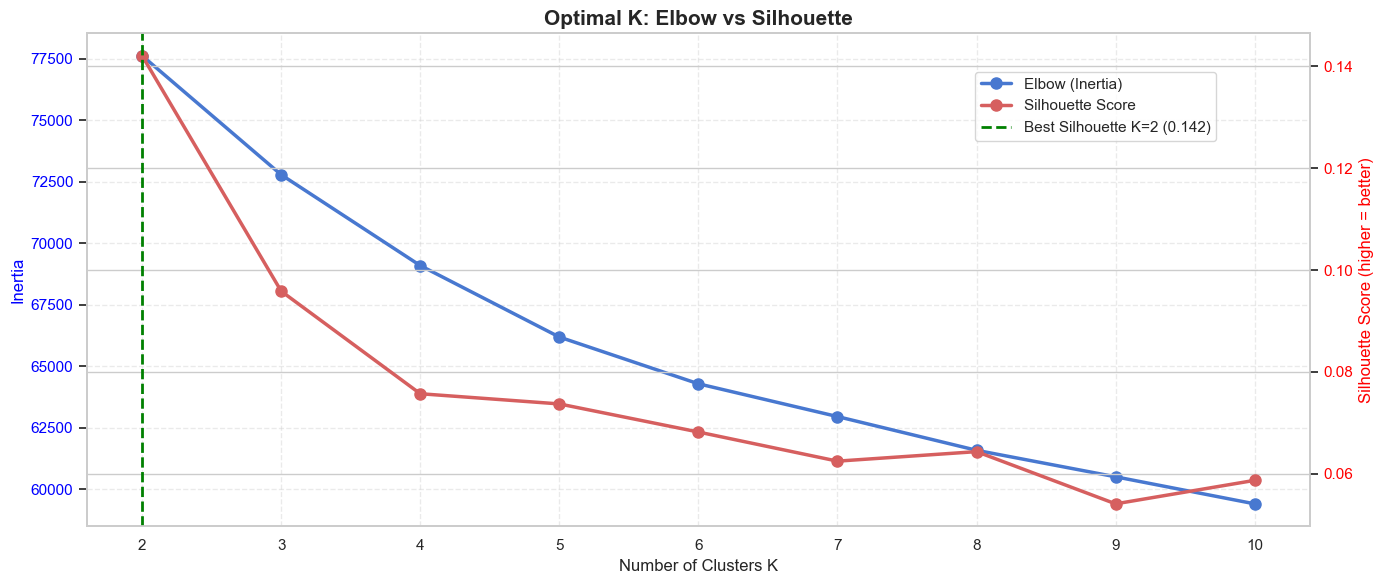

Silhouette suggests K = 2  (score = 0.142)
Using optimal_k = 4 for business interpretability


In [76]:
km_numeric_cols = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
    'SatisfactionScore', 'NumberOfAddress', 'Complain',
    'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
    'DaySinceLastOrder', 'CashbackAmount'
]
km_categorical_cols = [
    'PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode',
    'Gender', 'PreferedOrderCat', 'MaritalStatus'
]

km_numeric_cols     = [c for c in km_numeric_cols     if c in df.columns]
km_categorical_cols = [c for c in km_categorical_cols if c in df.columns]

for col in km_numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())
for col in km_categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

km_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), km_numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), km_categorical_cols)
])

km_features       = km_numeric_cols + km_categorical_cols
X_km_preprocessed = km_preprocessor.fit_transform(df[km_features])

K_range              = range(2, 11)
inertias             = []
silhouette_scores_km = []

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_km_preprocessed)
    inertias.append(km.inertia_)
    silhouette_scores_km.append(silhouette_score(X_km_preprocessed, lbl))

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(K_range, inertias, 'bo-', linewidth=2.5, markersize=8, label='Elbow (Inertia)')
ax1.set_xlabel('Number of Clusters K', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores_km, 'ro-', linewidth=2.5, markersize=8, label='Silhouette Score')
ax2.set_ylabel('Silhouette Score (higher = better)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

best_k_km = list(K_range)[np.argmax(silhouette_scores_km)]
best_sil  = max(silhouette_scores_km)
plt.axvline(x=best_k_km, color='green', linestyle='--', linewidth=2,
            label=f'Best Silhouette K={best_k_km} ({best_sil:.3f})')
plt.title('Optimal K: Elbow vs Silhouette', fontsize=15, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

print(f'Silhouette suggests K = {best_k_km}  (score = {best_sil:.3f})')
print('Using optimal_k = 4 for business interpretability')

K-Means clustering complete  (K = 4)

Cluster sizes:
Cluster
0     762
1    2075
2    1918
3     875
Name: count, dtype: int64


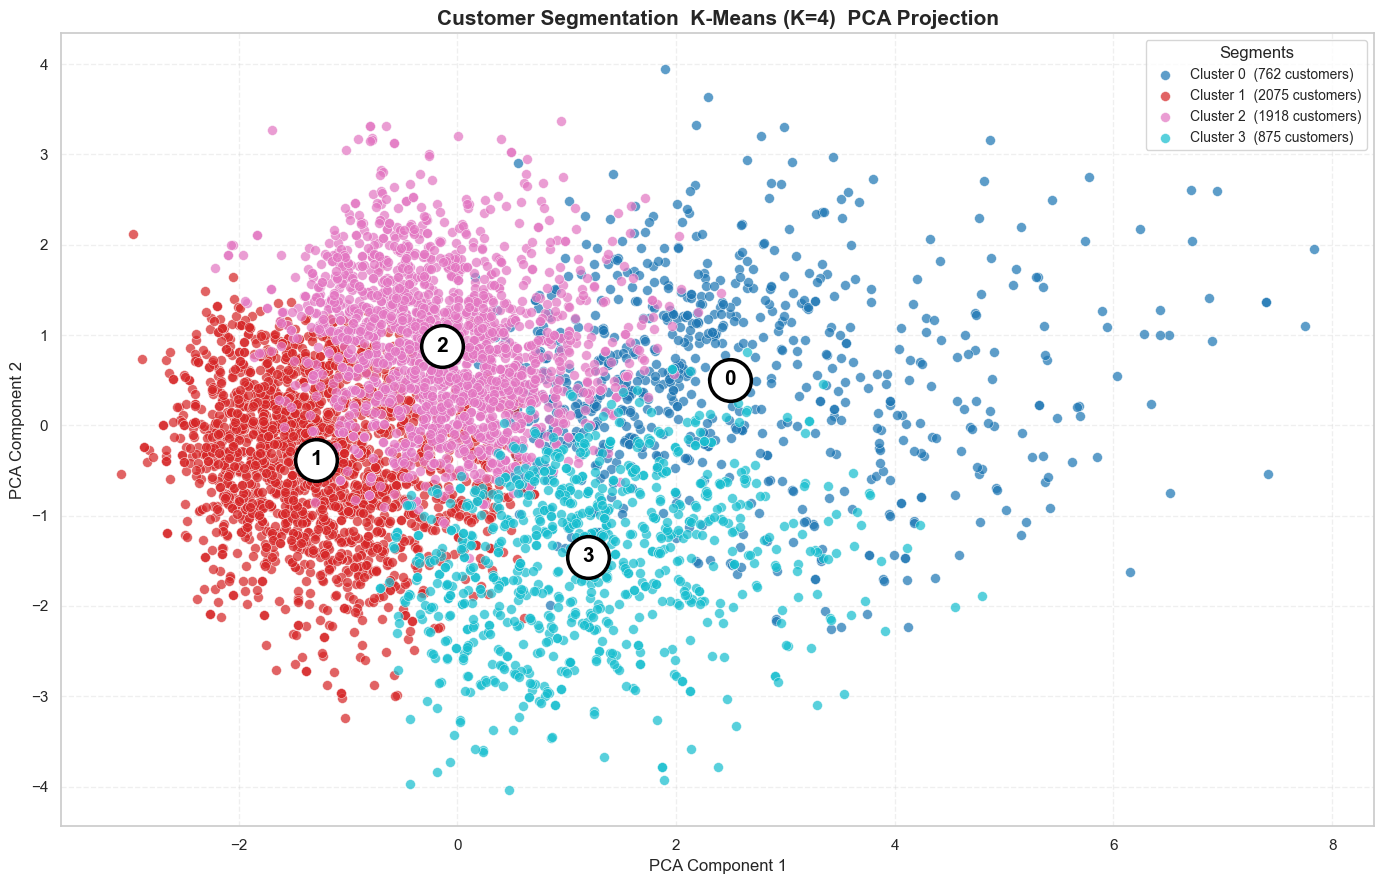

In [77]:
optimal_k = 4

km_pipeline = SKPipeline([
    ('preprocessor', km_preprocessor),
    ('kmeans', KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10))
])

df['Cluster'] = km_pipeline.fit_predict(df[km_features])

print(f'K-Means clustering complete  (K = {optimal_k})')
print('\nCluster sizes:')
print(df['Cluster'].value_counts().sort_index())

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_km_preprocessed)

plt.figure(figsize=(14, 9))
colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))

for i in range(optimal_k):
    pts = X_pca[df['Cluster'] == i]
    plt.scatter(pts[:, 0], pts[:, 1], c=[colors[i]],
                label=f'Cluster {i}  ({len(pts)} customers)',
                alpha=0.72, s=50, edgecolors='white', linewidth=0.4)
    centroid = pts.mean(axis=0)
    plt.scatter(*centroid, c='white', edgecolors='black', s=900, linewidth=2.5, zorder=5)
    plt.text(*centroid, str(i), fontsize=15, fontweight='bold',
             ha='center', va='center', color='black', zorder=6)

plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.title(f'Customer Segmentation  K-Means (K={optimal_k})  PCA Projection',
          fontsize=15, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Segments', fontsize=10)
plt.tight_layout()
plt.show()

In [78]:
km_preprocessor2 = ColumnTransformer(transformers=[
    ('num', SKPipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler())
    ]), km_numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), km_categorical_cols)
])

km_pipeline2 = SKPipeline([
    ('preprocessor', km_preprocessor2),
    ('kmeans', KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10))
])

df['Cluster'] = km_pipeline2.fit_predict(df[km_features])

print('=' * 110)
print('          DETAILED CUSTOMER SEGMENT ANALYSIS  K-Means')
print('=' * 110)

overall_means = df[km_numeric_cols].mean().round(2)
overall_churn = df['Churn'].mean() * 100

CLUSTER_LABELS = {
    0: 'Loyal & Stable Customers',
    1: 'High-Value Active Buyers',
    2: 'New & At-Risk Customers',
    3: 'Inactive / Disengaged Customers',
}

for cluster in range(optimal_k):
    cdf  = df[df['Cluster'] == cluster]
    size = len(cdf)
    perc = size / len(df) * 100

    print(f'\n CLUSTER {cluster}  {CLUSTER_LABELS.get(cluster, "")}   {size:,} customers ({perc:.1f}%)')
    print('-' * 100)

    means = cdf[km_numeric_cols].mean().round(2)
    print('Numeric Profile (vs. overall average):')
    for col in km_numeric_cols:
        diff  = means[col] - overall_means[col]
        arrow = 'UP' if diff > 0 else 'DOWN'
        print(f'   {col:35}: {means[col]:7.2f}  {arrow} ({diff:+.2f})')

    print('\nMost Common Categories:')
    for col in km_categorical_cols:
        mode_val = cdf[col].mode()[0]
        mode_pct = cdf[col].value_counts(normalize=True).iloc[0] * 100
        print(f'   {col:35}: {mode_val}  ({mode_pct:.1f}%)')

    churn_rate   = cdf['Churn'].mean() * 100
    avg_cashback = cdf['CashbackAmount'].mean()
    avg_satisf   = cdf['SatisfactionScore'].mean()

    print(f'\nKey Business Metrics:')
    print(f'   Churn Rate       : {churn_rate:.1f}%  {"[HIGH]" if churn_rate > overall_churn + 5 else ""}')
    print(f'   Avg Cashback     : {avg_cashback:.2f}')
    print(f'   Avg Satisfaction : {avg_satisf:.2f} / 5')
    print('-' * 100)

print('\nCluster analysis complete.')

          DETAILED CUSTOMER SEGMENT ANALYSIS  K-Means

 CLUSTER 0  Loyal & Stable Customers   762 customers (13.5%)
----------------------------------------------------------------------------------------------------
Numeric Profile (vs. overall average):
   Tenure                             :   11.96  UP (+1.83)
   WarehouseToHome                    :   15.25  DOWN (-0.32)
   HourSpendOnApp                     :    3.04  UP (+0.11)
   NumberOfDeviceRegistered           :    3.80  UP (+0.11)
   SatisfactionScore                  :    3.14  UP (+0.07)
   NumberOfAddress                    :    3.81  DOWN (-0.40)
   Complain                           :    0.28  DOWN (+0.00)
   OrderAmountHikeFromlastYear        :   15.47  DOWN (-0.20)
   CouponUsed                         :    4.99  UP (+3.27)
   OrderCount                         :    8.73  UP (+5.77)
   DaySinceLastOrder                  :    8.07  UP (+3.61)
   CashbackAmount                     :  200.27  UP (+23.05)

Most Common Ca

### 15.3 DBSCAN Clustering

**DBSCAN** (Density-Based Spatial Clustering) discovers arbitrarily-shaped clusters
and labels outliers as **noise (-1)** — no need to specify K in advance.

In [79]:
db_numeric_features = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
    'NumberOfDeviceRegistered', 'SatisfactionScore',
    'NumberOfAddress', 'OrderAmountHikeFromlastYear',
    'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'
]
db_categorical_features = [
    'PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode',
    'Gender', 'PreferedOrderCat', 'MaritalStatus', 'Complain'
]

db_numeric_features     = [c for c in db_numeric_features     if c in df.columns]
db_categorical_features = [c for c in db_categorical_features if c in df.columns]

print(f'Numeric features    : {len(db_numeric_features)}')
print(f'Categorical features: {len(db_categorical_features)}')

Numeric features    : 11
Categorical features: 7


In [80]:
df[db_numeric_features] = df[db_numeric_features].fillna(df[db_numeric_features].median())
for col in db_categorical_features:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print('Missing values after fill:', df[db_numeric_features + db_categorical_features].isnull().sum().sum())

db_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), db_numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
     db_categorical_features)
])

X_db_processed = db_preprocessor.fit_transform(df)

dbscan    = DBSCAN(eps=3, min_samples=5, n_jobs=-1)
db_labels = dbscan.fit_predict(X_db_processed)

df['Cluster'] = db_labels

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_count   = (db_labels == -1).sum()
print(f'Clusters found (excluding noise): {n_clusters_db}')
print(f'Noise points (Cluster = -1)     : {noise_count}')

Missing values after fill: 0
Clusters found (excluding noise): 5
Noise points (Cluster = -1)     : 206


In [81]:
if len(set(db_labels)) > 1:
    mask = db_labels != -1
    if mask.sum() > 10:
        sil = silhouette_score(X_db_processed[mask], db_labels[mask])
        print(f'Silhouette Score (excl. noise): {sil:.4f}')
    else:
        print('Too few non-noise points for Silhouette Score')
else:
    print('Only one cluster or only noise detected')

Silhouette Score (excl. noise): 0.0938


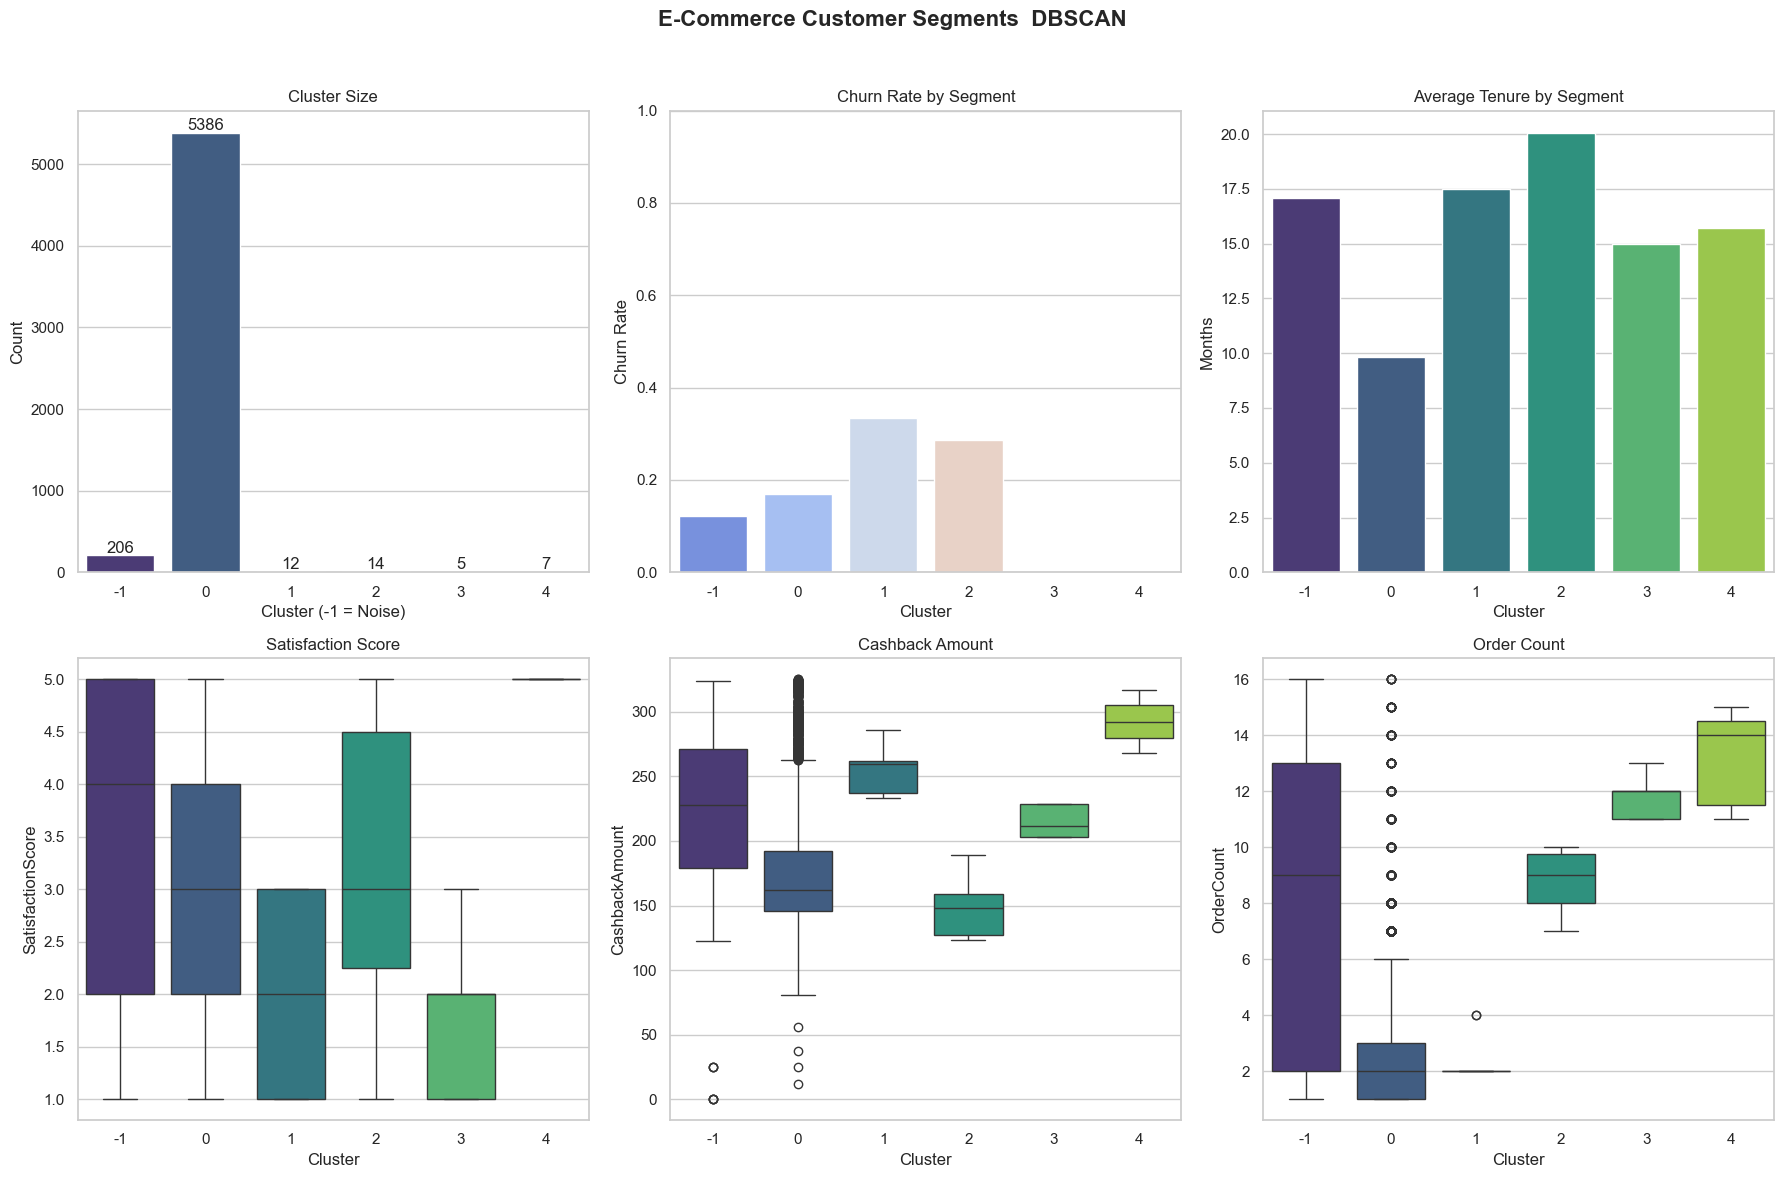

In [82]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('E-Commerce Customer Segments  DBSCAN', fontsize=16, fontweight='bold')

cluster_counts = df['Cluster'].value_counts().sort_index()
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Cluster Size')
axes[0, 0].set_xlabel('Cluster (-1 = Noise)')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(cluster_counts.values):
    axes[0, 0].text(i, v + 30, str(v), ha='center')

churn_by_cluster = df.groupby('Cluster')['Churn'].mean()
sns.barplot(x=churn_by_cluster.index, y=churn_by_cluster.values, ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('Churn Rate by Segment')
axes[0, 1].set_ylabel('Churn Rate')
axes[0, 1].set_ylim(0, 1)

tenure_by_cluster = df.groupby('Cluster')['Tenure'].mean()
sns.barplot(x=tenure_by_cluster.index, y=tenure_by_cluster.values, ax=axes[0, 2], palette='viridis')
axes[0, 2].set_title('Average Tenure by Segment')
axes[0, 2].set_ylabel('Months')

sns.boxplot(x='Cluster', y='SatisfactionScore', data=df, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Satisfaction Score')

sns.boxplot(x='Cluster', y='CashbackAmount', data=df, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Cashback Amount')

sns.boxplot(x='Cluster', y='OrderCount', data=df, ax=axes[1, 2], palette='viridis')
axes[1, 2].set_title('Order Count')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [83]:
X_num_db    = df[db_numeric_features].fillna(df[db_numeric_features].median())
X_cat_db    = pd.get_dummies(df[db_categorical_features], drop_first=True)
X_all_db    = pd.concat([X_num_db, X_cat_db], axis=1)

scaler_db   = StandardScaler()
X_scaled_db = scaler_db.fit_transform(X_all_db)

pca_db     = PCA(n_components=2, random_state=RANDOM_STATE)
pca_result = pca_db.fit_transform(X_scaled_db)

df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

fig_db = px.scatter(
    df, x='PCA1', y='PCA2', color='Cluster',
    size='OrderCount',
    hover_data=['Tenure', 'SatisfactionScore', 'CashbackAmount',
                'Churn', 'DaySinceLastOrder'],
    color_continuous_scale='viridis',
    title='Customer Segments  DBSCAN + PCA Projection',
    labels={'Cluster': 'DBSCAN Segment',
            'PCA1': 'Principal Component 1',
            'PCA2': 'Principal Component 2'},
    opacity=0.85, width=1100, height=700
)
fig_db.update_traces(marker=dict(line=dict(width=0.5, color='white')))
fig_db.update_layout(
    title_font_size=20,
    plot_bgcolor='rgba(248,249,250,0.95)',
    paper_bgcolor='white'
)
explained = pca_db.explained_variance_ratio_
fig_db.add_annotation(
    text=f'Explained Variance:<br>PC1 = {explained[0]:.1%}<br>PC2 = {explained[1]:.1%}',
    xref='paper', yref='paper', x=0.02, y=0.05, showarrow=False,
    font=dict(size=12, color='gray'),
    bgcolor='rgba(255,255,255,0.8)', bordercolor='gray', borderpad=4
)
fig_db.show()

In [84]:
print('DBSCAN CUSTOMER SEGMENT ANALYSIS & INTERPRETATION')
print('=' * 85)

segment_profile = df.groupby('Cluster').agg({
    'Churn':             ['count', 'mean'],
    'Tenure':            ['mean', 'median'],
    'SatisfactionScore': 'mean',
    'CashbackAmount':    'mean',
    'OrderCount':        'mean',
    'DaySinceLastOrder': 'mean',
    'WarehouseToHome':   'mean',
    'NumberOfAddress':   'mean',
    'HourSpendOnApp':    'mean',
    'Complain':          'mean'
}).round(3)

segment_profile.columns = [
    'Customer_Count', 'Churn_Rate', 'Avg_Tenure', 'Median_Tenure',
    'Avg_Satisfaction', 'Avg_Cashback', 'Avg_Orders_per_Month',
    'Avg_Days_Since_Last_Order', 'Avg_Warehouse_Distance',
    'Avg_Num_Addresses', 'Avg_Hours_on_App', 'Complaint_Rate'
]
segment_profile = segment_profile.reset_index()

for _, row in segment_profile.iterrows():
    cluster        = row['Cluster']
    count          = int(row['Customer_Count'])
    churn_rate     = row['Churn_Rate']
    avg_tenure     = row['Avg_Tenure']
    avg_satisf     = row['Avg_Satisfaction']
    avg_orders     = row['Avg_Orders_per_Month']
    avg_cashback   = row['Avg_Cashback']
    days_since     = row['Avg_Days_Since_Last_Order']
    complaint_rate = row['Complaint_Rate']

    if cluster == -1:
        seg_name = 'OUTLIERS / NOISE'
        desc     = 'Customers with unusual or extreme behaviour.'
    elif churn_rate > 0.45:
        seg_name = 'HIGH-RISK CHURN SEGMENT'
        desc     = 'Very likely to leave the platform soon.'
    elif avg_tenure > 20 and churn_rate < 0.15:
        seg_name = 'LOYAL & STABLE CUSTOMERS'
        desc     = 'Long-term, reliable, and satisfied customers.'
    elif avg_orders > 6:
        seg_name = 'HIGH-FREQUENCY BUYERS'
        desc     = 'Very active shoppers who order frequently.'
    elif avg_cashback > 220:
        seg_name = 'PREMIUM / HIGH-VALUE CUSTOMERS'
        desc     = 'High cashback receivers  likely high spenders.'
    elif avg_satisf < 2.5:
        seg_name = 'DISSATISFIED CUSTOMERS'
        desc     = 'Low satisfaction  at risk of churning.'
    else:
        seg_name = 'REGULAR / NEW CUSTOMERS'
        desc     = 'Average behaviour customers.'

    print(f'\n SEGMENT {cluster}  {seg_name}  ({count:,} customers)')
    print(f'   {desc}')
    print(f'   Churn Rate          : {churn_rate:.1%}  {"[HIGH]" if churn_rate > 0.3 else ""}')
    print(f'   Avg Tenure          : {avg_tenure:.1f} months')
    print(f'   Satisfaction Score  : {avg_satisf:.2f}/5')
    print(f'   Avg Monthly Orders  : {avg_orders:.2f}')
    print(f'   Avg Cashback        : {avg_cashback:.2f}')
    print(f'   Days Since Last Ord : {days_since:.1f}')
    print(f'   Complaint Rate      : {complaint_rate:.1%}')
    print('   Recommendation:')
    if cluster == -1:
        print('     Investigate separately  may be bots or data errors.')
    elif churn_rate > 0.4:
        print('     Urgent retention campaign (discounts, personalised offers).')
    elif avg_tenure > 20:
        print('     Loyalty rewards, VIP treatment, referral incentives.')
    elif avg_orders > 6:
        print('     Upsell / cross-sell; consider premium subscriptions.')
    elif avg_satisf < 2.8:
        print('     Focus on service improvement and complaint resolution.')
    else:
        print('     Targeted promotions to increase engagement.')

print('\n' + '='*85)
print('End of Segment Analysis')

display(segment_profile.style
    .background_gradient(cmap='viridis', subset=['Churn_Rate'])
    .format({
        'Churn_Rate':                '{:.1%}',
        'Avg_Tenure':                '{:.1f}',
        'Avg_Satisfaction':          '{:.2f}',
        'Avg_Cashback':              '{:.2f}',
        'Avg_Orders_per_Month':      '{:.2f}',
        'Avg_Days_Since_Last_Order': '{:.1f}',
        'Complaint_Rate':            '{:.1%}'
    }))

DBSCAN CUSTOMER SEGMENT ANALYSIS & INTERPRETATION

 SEGMENT -1.0  OUTLIERS / NOISE  (206 customers)
   Customers with unusual or extreme behaviour.
   Churn Rate          : 12.1%  
   Avg Tenure          : 17.1 months
   Satisfaction Score  : 3.31/5
   Avg Monthly Orders  : 8.59
   Avg Cashback        : 222.26
   Days Since Last Ord : 8.9
   Complaint Rate      : 28.2%
   Recommendation:
     Investigate separately  may be bots or data errors.

 SEGMENT 0.0  REGULAR / NEW CUSTOMERS  (5,386 customers)
   Average behaviour customers.
   Churn Rate          : 17.0%  
   Avg Tenure          : 9.8 months
   Satisfaction Score  : 3.06/5
   Avg Monthly Orders  : 2.71
   Avg Cashback        : 175.22
   Days Since Last Ord : 4.3
   Complaint Rate      : 28.5%
   Recommendation:
     Targeted promotions to increase engagement.

 SEGMENT 1.0  PREMIUM / HIGH-VALUE CUSTOMERS  (12 customers)
   High cashback receivers  likely high spenders.
   Churn Rate          : 33.3%  [HIGH]
   Avg Tenure       

,Cluster,Customer_Count,Churn_Rate,Avg_Tenure,Median_Tenure,Avg_Satisfaction,Avg_Cashback,Avg_Orders_per_Month,Avg_Days_Since_Last_Order,Avg_Warehouse_Distance,Avg_Num_Addresses,Avg_Hours_on_App,Complaint_Rate
0,-1,206,12.1%,17.1,18.000000,3.31,222.26,8.59,8.9,19.932000,5.495000,2.869000,28.2%
1,0,5386,17.0%,9.8,9.000000,3.06,175.22,2.71,4.3,15.373000,4.147000,2.935000,28.5%
2,1,12,33.3%,17.5,17.500000,2.00,256.10,2.33,9.8,25.500000,6.167000,2.833000,100.0%
3,2,14,28.6%,20.1,20.000000,3.14,145.71,8.64,7.8,16.500000,9.786000,3.500000,0.0%
4,3,5,0.0%,15.0,14.000000,1.80,214.84,11.80,2.2,27.600000,5.200000,3.400000,0.0%
5,4,7,0.0%,15.7,17.000000,5.00,292.47,13.14,14.7,9.000000,2.857000,3.429000,0.0%
